<a href="https://colab.research.google.com/github/Oliver-code26/Hackathon_Where_You_Wanna_Live/blob/Areeba89023-patch-1/Areeba_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# You Wanna Live Where? - France, Germany and United Kingdom EDA

## Objectives

- Perform Exploratory Data Analysis on France, Germany and the United Kingdom as part of the wider Western Europe analysis.
- Compare cost of living, rent, groceries, restaurant prices and local purchasing power.
- Investigate changes in these measures from 2018 to 2026.
- Evaluate France, Germany and the United Kingdom using the project-defined **Affordability Rule**.
- Produce findings that can contribute to the wider Western Europe analysis and Streamlit dashboard.

## Inputs

- The `cost_of_living.csv` dataset.
- Python libraries: pandas, numpy, matplotlib and seaborn.

## Outputs

- Descriptive statistics.
- Country-level comparisons.
- Time-series visualisations.
- Purchasing power comparisons.
- Affordability Rule analysis.

## Additional Comments

This notebook focuses on France, Germany and the United Kingdom as part of the wider Western Europe analysis.

The project-defined **Affordability Rule** is used as a comparative measure within this project and should not be interpreted as an official affordability threshold.

In [5]:
print(country_summ.to_string())

print("\nAFFORDABILITY SUMMARY")
print(affordability_summary.to_string())

               cost_of_living_index              rent_index              cost_of_living_plus_rent_index              groceries_index              restaurant_price_index              local_purchasing_power_index              
                               mean median   std       mean median   std                           mean median   std            mean median   std                   mean median   std                         mean median    std
country                                                                                                                                                                                                                         
France                        72.00   74.1  7.86      24.66   25.3  2.91                          49.72   50.8  5.01           70.66   68.6  5.19                  69.36   71.8  8.44                        92.31   86.2  14.65
Germany                       66.23   65.6  4.72      26.62   26.8  2.19                          47

In [1]:
# ============================================================
# STEP 1 - SET UP AND LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the project GitHub repository
df = pd.read_csv(
    "https://raw.githubusercontent.com/Oliver-code26/Hackathon_Where_You_Wanna_Live/Areeba89023-patch-1/cost_of_living.csv"
)

# Select assigned countries
my_countries = ["France", "Germany", "United Kingdom"]

my_df = df[df["country"].isin(my_countries)].copy()

# Display basic information
print("Dataset shape:", my_df.shape)

print("\nCountries:")
print(my_df["country"].value_counts())

print("\nYears:")
print(sorted(my_df["year"].unique()))

print("\nFirst rows:")
display(my_df.head(10))

Dataset shape: (27, 10)

Countries:
country
Germany           9
United Kingdom    9
France            9
Name: count, dtype: int64

Years:
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

First rows:


,country,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,year,period,continent
23,Germany,68.7,24.6,49.0,64.9,66.9,138.3,2026,year,Europe
27,United Kingdom,67.8,32.1,51.9,62.8,72.9,122.6,2026,year,Europe
28,France,67.7,22.3,47.5,73.2,66.2,118.5,2026,year,Europe
173,United Kingdom,59.2,30.0,46.3,54.8,65.3,119.9,2025,year,Europe
177,Germany,58.4,22.4,42.4,56.7,57.5,127.1,2025,year,Europe
178,France,58.0,19.4,41.0,63.6,56.1,110.0,2025,year,Europe
314,France,66.0,22.3,45.3,68.6,57.9,83.4,2024,year,Europe
320,United Kingdom,63.7,33.5,49.4,55.5,63.9,90.1,2024,year,Europe
322,Germany,62.7,26.3,45.4,57.6,52.5,101.0,2024,year,Europe
460,France,68.7,24.6,47.5,65.1,66.9,86.2,2023,year,Europe


In [2]:
# ============================================================
# STEP 2 - DESCRIPTIVE ANALYSIS
# ============================================================

print("GENERAL DESCRIPTIVE STATISTICS")

display(my_df.describe().round(2))

print("\nCOUNTRY SUMMARY")

country_summ = (
    my_df.groupby("country")[
        [
            "cost_of_living_index",
            "rent_index",
            "cost_of_living_plus_rent_index",
            "groceries_index",
            "restaurant_price_index",
            "local_purchasing_power_index"
        ]
    ]
    .agg(["mean", "median", "std"])
    .round(2)
)

display(country_summ)

GENERAL DESCRIPTIVE STATISTICS


,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,year
count,27.00,27.00,27.00,27.00,27.00,27.00,27.00
mean,68.35,27.50,49.14,60.50,67.83,102.00,2022.00
std,6.39,3.58,3.83,8.69,8.06,16.35,2.63
min,58.00,19.40,41.00,47.70,52.50,74.10,2018.00
25%,64.50,25.35,46.80,54.50,62.60,89.45,2020.00
50%,67.70,27.60,49.00,57.60,66.90,101.20,2022.00
75%,72.55,29.90,51.70,66.50,73.50,113.10,2024.00
max,83.90,33.50,57.20,78.10,83.90,138.30,2026.00



COUNTRY SUMMARY


cost_of_living_index              rent_index               \
                               mean median   std       mean median   std   
country                                                                    
France                        72.00   74.1  7.86      24.66   25.3  2.91   
Germany                       66.23   65.6  4.72      26.62   26.8  2.19   
United Kingdom                66.81   67.3  5.07      31.23   31.6  1.67   

               cost_of_living_plus_rent_index              groceries_index  \
                                         mean median   std            mean   
country                                                                      
France                                  49.72   50.8  5.01           70.66   
Germany                                 47.60   47.8  3.07           55.50   
United Kingdom                          50.09   49.4  3.01           55.33   

                            restaurant_price_index               \
               median   std                   mean median   std   
country                                                           
France           68.6  5.19                  69.36   71.8  8.44   
Germany          54.7  4.73                  61.71   61.6  5.76   
United Kingdom   55.5  4.71                  72.43   72.9  6.15   

               local_purchasing_power_index                
                                       mean median    std  
country                                                    
France                                92.31   86.2  14.65  
Germany                              112.71  107.6  14.78  
United Kingdom                       100.98   98.9  14.14

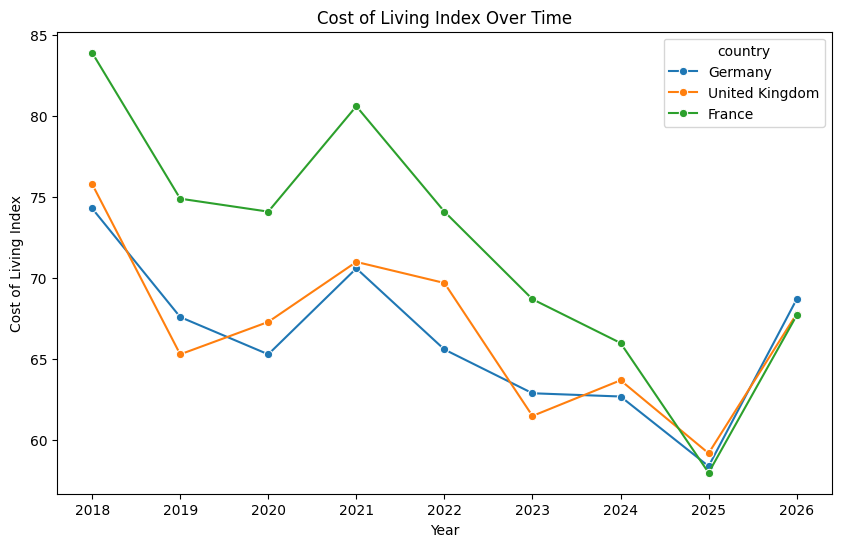

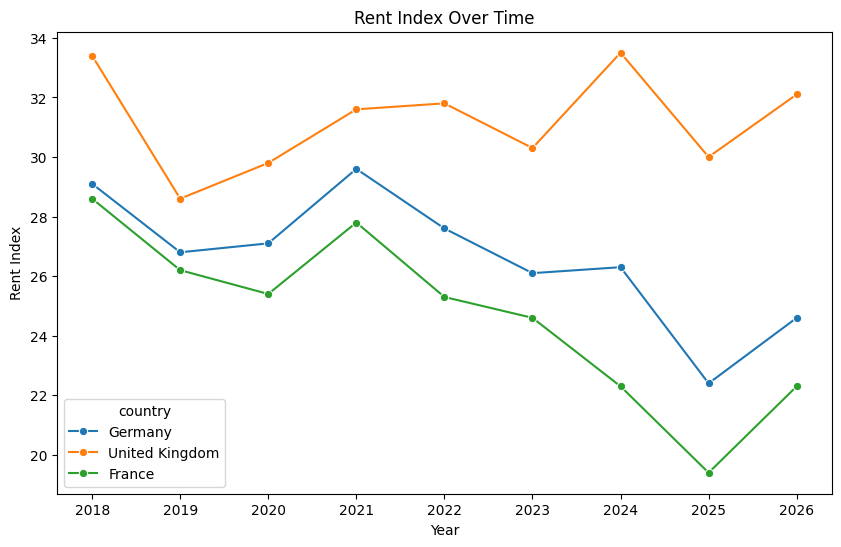

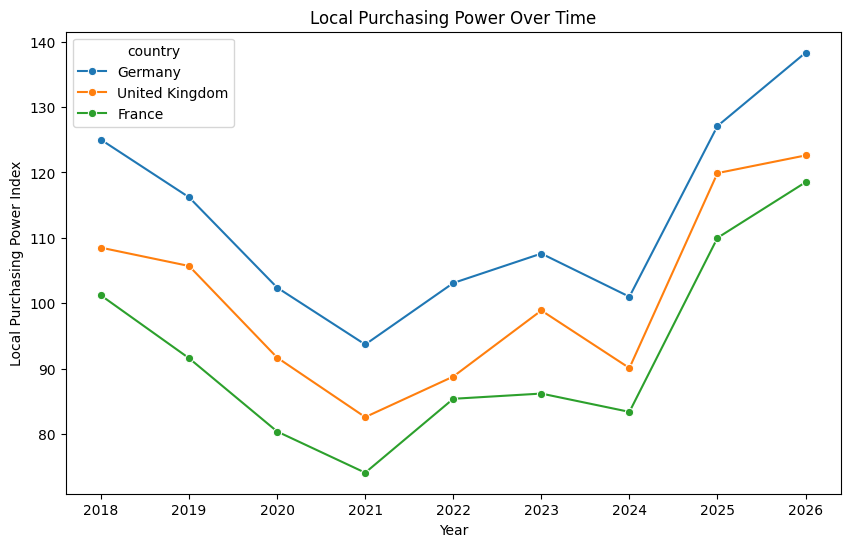

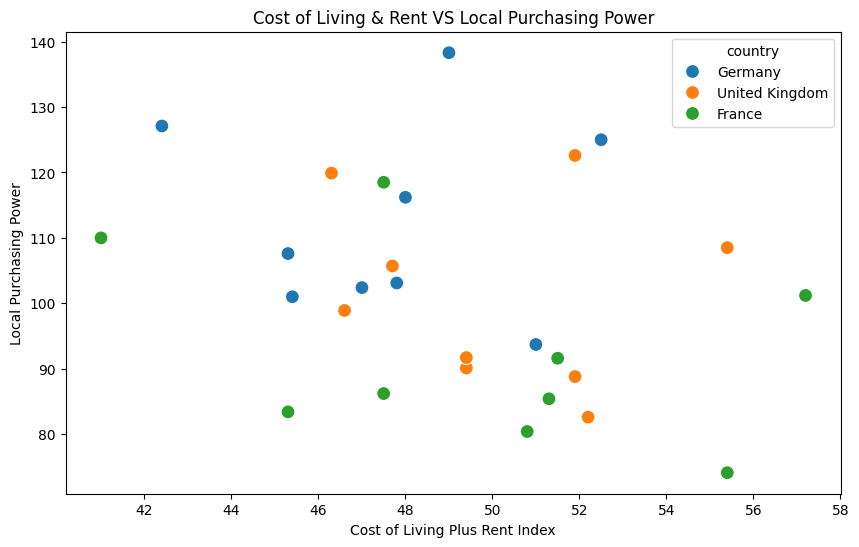

In [3]:
# ============================================================
# STEP 3 - VISUAL ANALYSIS
# ============================================================

# 1. Cost of Living
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=my_df,
    x="year",
    y="cost_of_living_index",
    hue="country",
    marker="o"
)
plt.title("Cost of Living Index Over Time")
plt.xlabel("Year")
plt.ylabel("Cost of Living Index")
plt.show()

# 2. Rent
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=my_df,
    x="year",
    y="rent_index",
    hue="country",
    marker="o"
)
plt.title("Rent Index Over Time")
plt.xlabel("Year")
plt.ylabel("Rent Index")
plt.show()

# 3. Local Purchasing Power
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=my_df,
    x="year",
    y="local_purchasing_power_index",
    hue="country",
    marker="o"
)
plt.title("Local Purchasing Power Over Time")
plt.xlabel("Year")
plt.ylabel("Local Purchasing Power Index")
plt.show()

# 4. Cost of Living + Rent vs Purchasing Power
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=my_df,
    x="cost_of_living_plus_rent_index",
    y="local_purchasing_power_index",
    hue="country",
    s=100
)
plt.title("Cost of Living & Rent VS Local Purchasing Power")
plt.xlabel("Cost of Living Plus Rent Index")
plt.ylabel("Local Purchasing Power")
plt.show()

AFFORDABILITY RULE BY YEAR AND COUNTRY


,year,country,affordability_rule
1120,2018,France,1.77
1131,2018,Germany,2.38
1130,2018,United Kingdom,1.96
999,2019,France,1.78
1011,2019,Germany,2.42
1012,2019,United Kingdom,2.22
870,2020,France,1.58
885,2020,Germany,2.18
883,2020,United Kingdom,1.86
733,2021,France,1.34



COUNTRY AFFORDABILITY SUMMARY


,mean,median,min,max,std
country,,,,,
France,1.89,1.78,1.34,2.68,0.43
Germany,2.38,2.38,1.84,3.00,0.35
United Kingdom,2.02,1.96,1.58,2.59,0.33


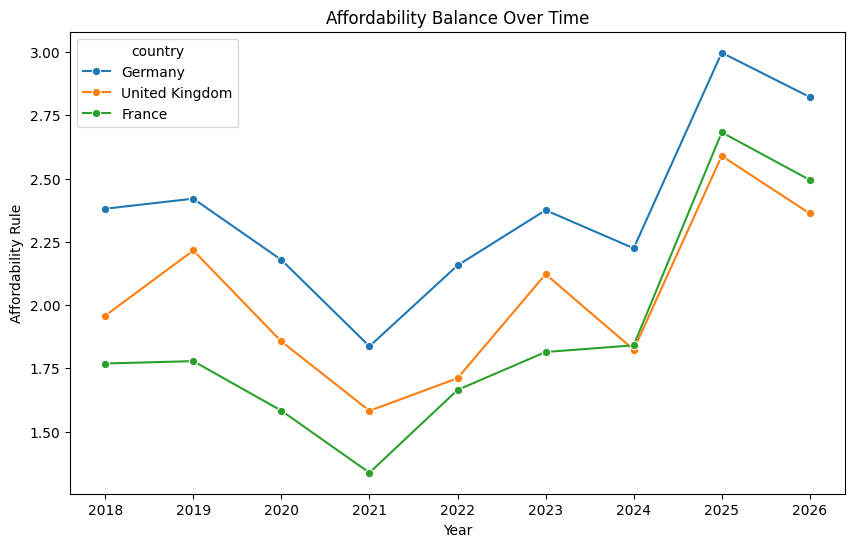

In [4]:
# ============================================================
# STEP 4 - AFFORDABILITY RULE
# ============================================================

# Project-defined Affordability Rule
my_df["affordability_rule"] = (
    my_df["local_purchasing_power_index"] /
    my_df["cost_of_living_plus_rent_index"]
)

# Affordability results by year and country
print("AFFORDABILITY RULE BY YEAR AND COUNTRY")

affordability_by_year = (
    my_df[["year", "country", "affordability_rule"]]
    .sort_values(["year", "country"])
)

display(affordability_by_year.round(2))

# Country-level affordability summary
print("\nCOUNTRY AFFORDABILITY SUMMARY")

affordability_summary = (
    my_df.groupby("country")["affordability_rule"]
    .agg(["mean", "median", "min", "max", "std"])
    .round(2)
)

display(affordability_summary)

# Affordability trend
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=my_df,
    x="year",
    y="affordability_rule",
    hue="country",
    marker="o"
)
plt.title("Affordability Balance Over Time")
plt.xlabel("Year")
plt.ylabel("Affordability Rule")
plt.show()

# Conclusions and Next Steps

## Key Findings

The analysis compared France, Germany and the United Kingdom across cost of living, rent, groceries, restaurant prices and local purchasing power from 2018 to 2026.

- **France** had the highest average Cost of Living Index at **72.00**, compared with **66.81** for the United Kingdom and **66.23** for Germany.
- **The United Kingdom** had the highest average Rent Index at **31.23**, followed by Germany at **26.62** and France at **24.66**.
- When combining living costs and rent, Germany had the lowest average Cost of Living Plus Rent Index at **47.60**, while France was **49.72** and the United Kingdom was **50.09**.
- **Germany** had the highest average Local Purchasing Power Index at **112.71**, followed by the United Kingdom at **100.98** and France at **92.31**.
- Under the project-defined **Affordability Rule**, Germany achieved the highest average score at **2.38**, followed by the United Kingdom at **2.02** and France at **1.89**.

Overall, Germany performed strongest in this comparison because it combined the lowest average Cost of Living Plus Rent Index with the highest Local Purchasing Power Index and the highest Affordability Rule score. The United Kingdom had stronger purchasing power than France but also had the highest average rent. France had the highest average cost of living and the lowest local purchasing power of the three countries.

The **Affordability Rule is a project-defined comparative measure** and should not be interpreted as an official affordability threshold.

## Next Steps

The findings from France, Germany and the United Kingdom will contribute to the wider Western Europe analysis and the team's Streamlit dashboard.

The results can be combined with the analyses produced by the other team members to identify broader Western European patterns and support the final project conclusions.